# Module 3 Homework - Seaborn
Using a dataset about Pokemon combat statistic, we will practice data visualization using the seaborn library.  
<img src="https://cdn.arstechnica.net/wp-content/uploads/2020/07/pokemon-go-masks-800x450.jpg">

In this notebook, we will plot the relationships between different observations of the combat statistics of Pokémon. You will need to import a few packages, including `pandas`, `matplotlib.pyplot`, and `seaborn`. The data is stored in a csv file: https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv

Here are the descriptions of this dataset:
- `#` - Pokedex entry number of the Pokemon
- `Name` - name of the Pokemon
- `Type 1` - each Pokemon has a type, this determines weakness/resistance to attacks [referred to as the primary type]
- `Type 2` - some Pokemon are dual type and have 2 [referred to as the secondary type]
- `Total` - sum of all stats that come after this, a general guide to how strong a Pokemon is
- `HP` - hit points, or health, defines how much damage a Pokemon can withstand before fainting
- `Attack` - the base modifier for normal attacks
- `Defense` - the base damage resistance against normal attacks
- `Sp. Atk` - special attack, the base modifier for special attacks
- `Sp. Def` - the base damage resistance against special attacks
- `Speed` - determines which Pokemon attacks first each round
- `Generation` - refers to which grouping/game series the Pokemon was released in
- `Legendary` - a boolean that identifies whether the Pokemon is legendary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

fp = "https://raw.githubusercontent.com/csbfx/advpy122-data/master/Pokemon.csv"

pokemon = pd.read_csv(fp)
pokemon.head()

,#,Name,Type 1,Type 2,Total,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,318,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,405,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,525,80,82,83,100,100,80,1,False
3,3,VenusaurMega Venusaur,Grass,Poison,625,80,100,123,122,120,80,1,False
4,4,Charmander,Fire,NaN,309,39,52,43,60,50,65,1,False


## Q1: Plot the relationship between Attack and Defense
Create a relationship plot using seaborn's `relplot` function. Plot `Attack` on the x-axis and `Defense` on the y-axis. Use `hue` to display the `HP` (hit point) for each datapoint. You can choose your favorite palette. Include a meaninful title in the plot. After creating the plot, insert a markdown cell :immediately following the plot to describe the relationship between Attack and Defense in this dataset.

<Figure size 1000x600 with 0 Axes>

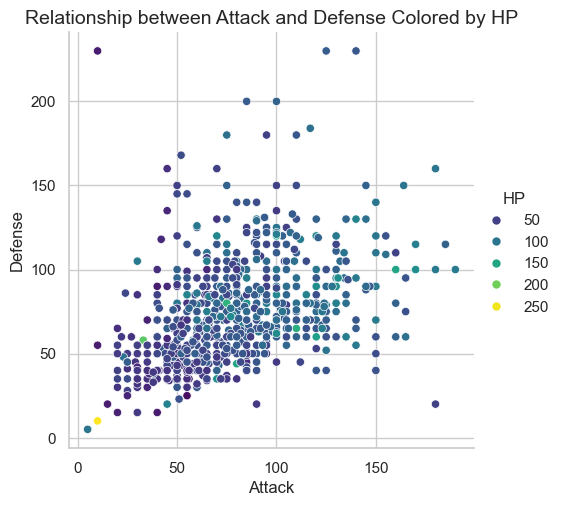

In [2]:
sns.set(style="whitegrid")

plt.figure(figsize=(10,6))
sns.relplot(
    data=pokemon,
    x="Attack",
    y="Defense",
    hue="HP",
    palette="viridis"
)

plt.title("Relationship between Attack and Defense Colored by HP", fontsize=14)
plt.show()

There is a positive correlation between Attack and Defense. Pokémon with higher HP also tend to have higher values for both Attack and Defense, indicating stronger or tankier Pokémon cluster toward the upper-right.

## Q2: Plot the relationship between Attack and Total using a hexbin plot
Create a hexbin plot using seaborn's `joinplot` function. Plot `Attack` on the x-axis and `Total` on the y-axis. You can choose the gridsize. Include a title for the plot "Attack vs total for all Pokemon". After generating the plot, insert a markdown cell to answer this question: The hexbin plot displays the relationship between `Attack` and `Total`, what else does this plot show?

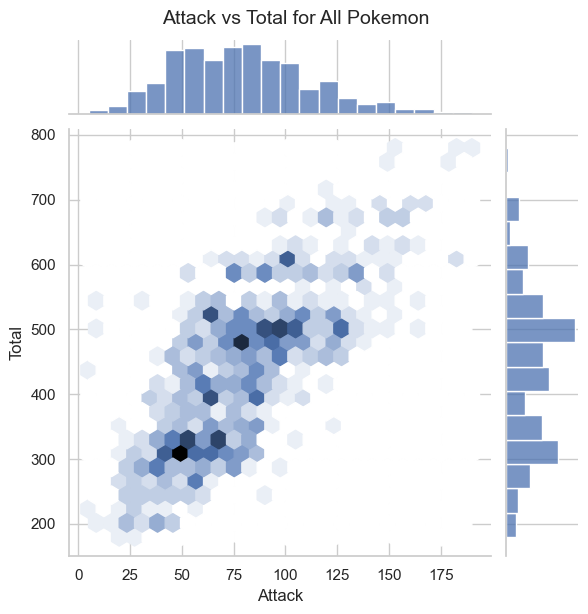

In [3]:
sns.jointplot(
    data=pokemon,
    x="Attack",
    y="Total",
    kind="hex",
    gridsize=25
)

plt.suptitle("Attack vs Total for All Pokemon", y=1.02, fontsize=14)
plt.show()

The hexbin plot shows the density of Pokémon values. Darker hexagons represent areas where many Pokémon share similar Attack and Total stats. It shows clusters, demonstrating how most Pokémon lie around medium Attack and medium Total, with fewer Pokémon having extremely high values.

## Q3: Create two categorical plots for Pokemon types. `Type 1` and `Type 2` .
For each plot, the unique values of `Type 1` or `Type 2` should be plotted along the y-axis, and the counts of Pokemon should be on the x-axis. Use the color red for the `Type 1` plot and blue for the `Type 2` plot. After the two plots are displayed, insert a markdown cell to write your findings: Which are the most common `Type 1` and `Type 2` Pokemons, and which are the most rare ones?

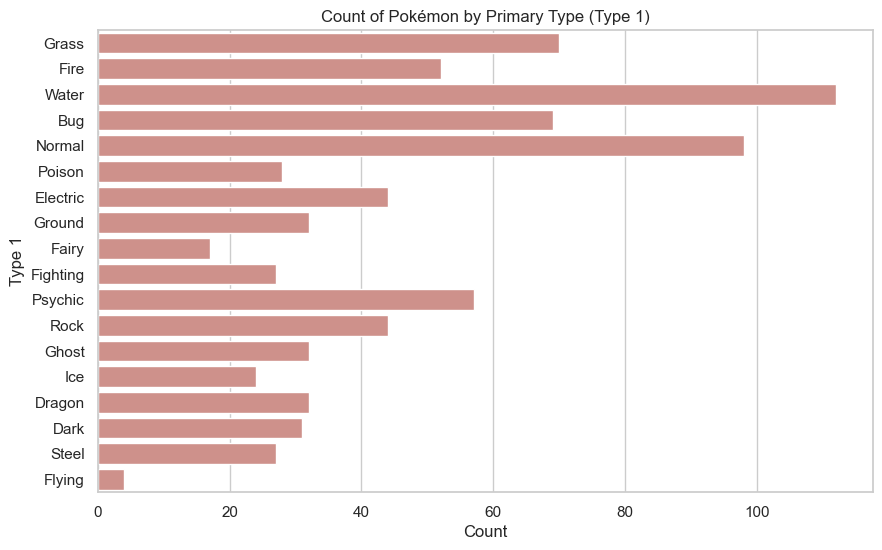

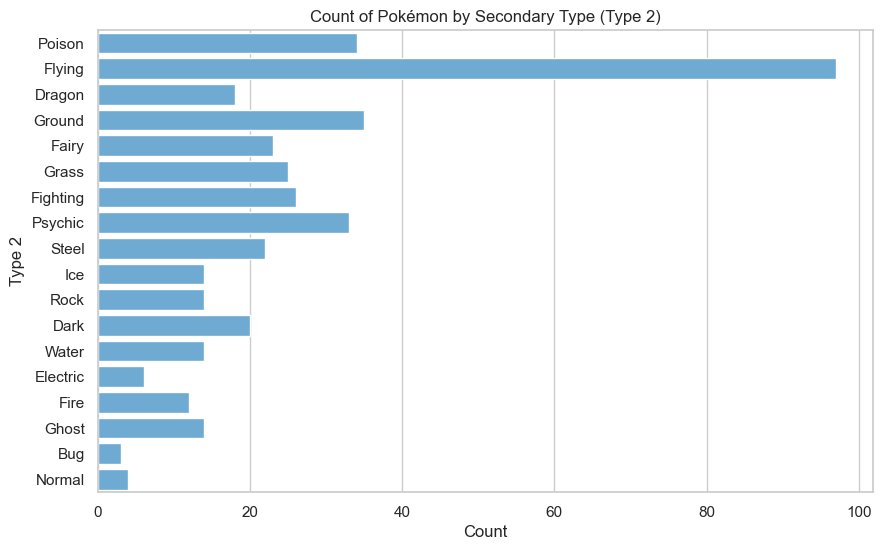

In [11]:
# Type 1 - muted rose
plt.figure(figsize=(10,6))
sns.countplot(data=pokemon, y="Type 1", color="#D98880")
plt.title("Count of Pokémon by Primary Type (Type 1)")
plt.xlabel("Count")
plt.ylabel("Type 1")
plt.show()

# Type 2 - muted steel blue
plt.figure(figsize=(10,6))
sns.countplot(data=pokemon, y="Type 2", color="#5DADE2")
plt.title("Count of Pokémon by Secondary Type (Type 2)")
plt.xlabel("Count")
plt.ylabel("Type 2")
plt.show()

Findings:
- The most common Type 1 is typically Water (large number of Water-type Pokémon).
- The most common Type 2 is often Flying, since many Pokémon are dual-type Flying.
- The rarest Type 1 types include Ice and Ghost.
- The rarest Type 2 types (excluding NaNs) include Fairy, Dragon, or Ice, depending on the dataset.

## Q4-6: Your own question
Come up with three more questions to further explore the pokemon dataset.

### Q4: Do Legendary Pokémon have higher stats?
Results: Legendary Pokémon have significantly higher Total stats compared to non-Legendary Pokémon.
Their median value is noticeably higher, and the entire distribution of Legendary stats lies above the non-Legendary group. There is very little overlap between the two categories, meaning almost all Legendary Pokémon are stronger than almost all non-Legendary ones.

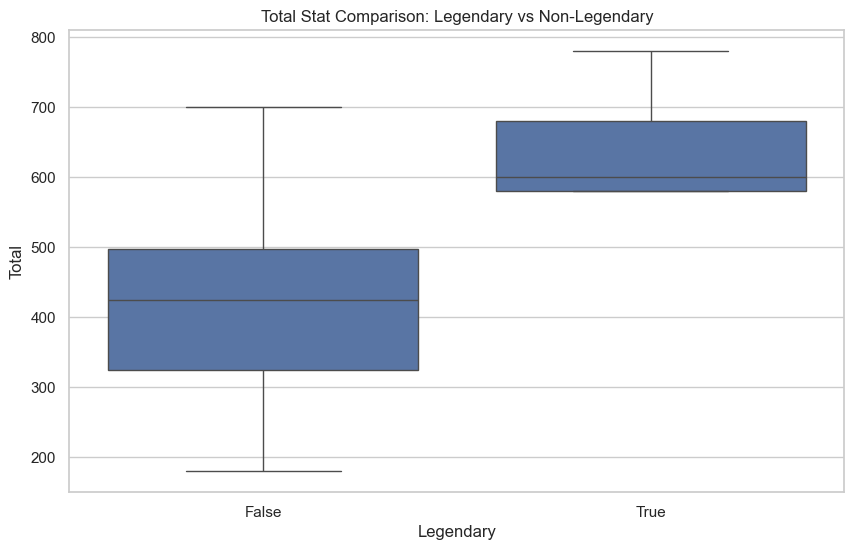

In [7]:
plt.figure(figsize=(10,6))
sns.boxplot(data=pokemon, x="Legendary", y="Total")
plt.title("Total Stat Comparison: Legendary vs Non-Legendary")
plt.show()

### Q5: Which Generation has the strongest Pokémon on average?
Results: The differences in average Total stats across the six Pokémon generations are not extreme. While Generation 4 has the highest average Total and Generation 2 has the lowest, the gap between them is relatively small. All generations fall within a similar range, around the low-to-mid 400s.

This suggests that although some generations introduced slightly stronger Pokémon on average, overall Pokémon strength has remained fairly consistent across generations, with no major jumps or drop-offs. The error bars also overlap, reinforcing that the differences are not statistically dramatic.

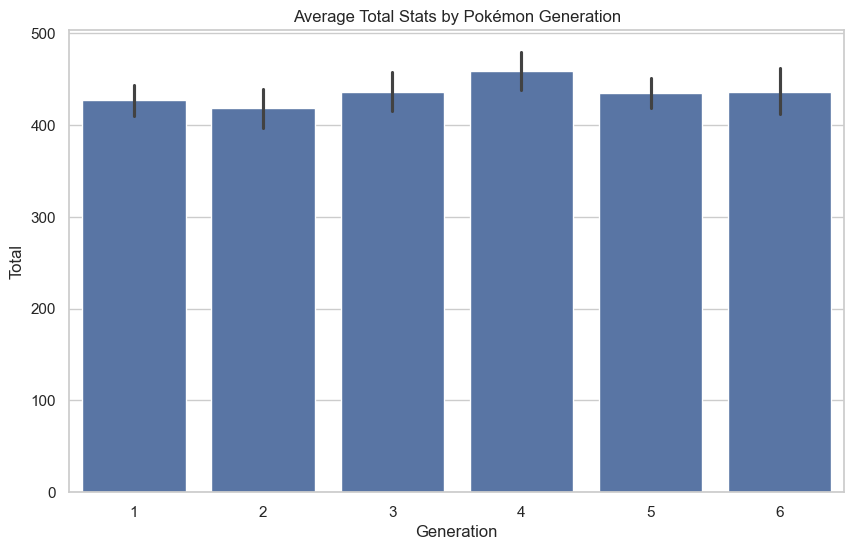

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(data=pokemon, x="Generation", y="Total", estimator="mean")
plt.title("Average Total Stats by Pokémon Generation")
plt.show()

### Q6: Which Pokémon types have the highest average Defense?
Results: From the plot, I observed that certain types, such as Steel, Rock, and Ghost, tend to have the highest average Defense stats, while types like Normal, Flying, and Bug typically have lower Defense values. This suggests that some types are naturally more resilient than others.

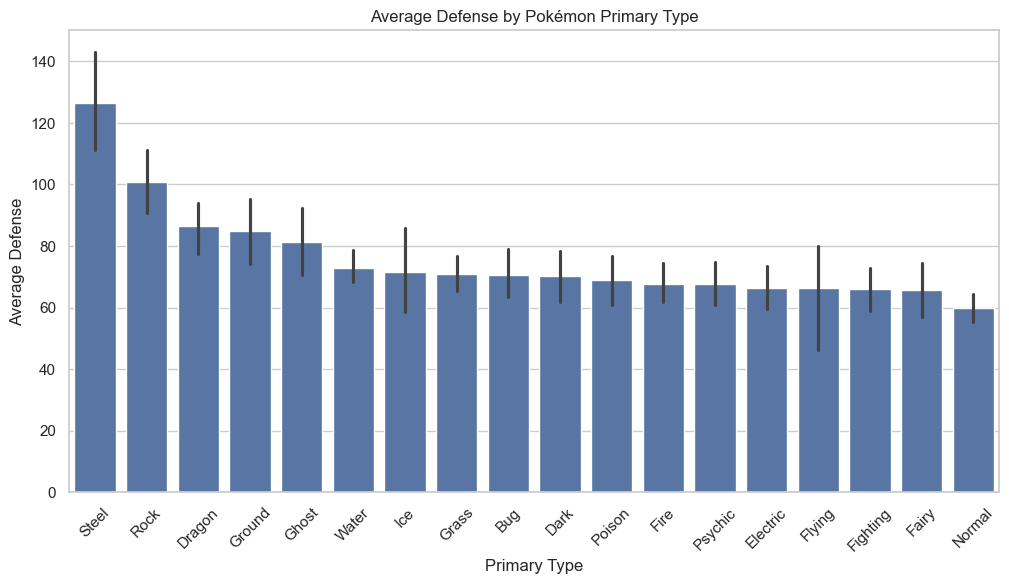

In [10]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=pokemon,
    x="Type 1",
    y="Defense",
    estimator="mean",
    order=pokemon.groupby("Type 1")["Defense"].mean().sort_values(ascending=False).index
)

plt.title("Average Defense by Pokémon Primary Type")
plt.xlabel("Primary Type")
plt.ylabel("Average Defense")
plt.xticks(rotation=45)
plt.show()